# Assignment 1 - Building a Vision Model with Keras

In this assignment, you will build a simple vision model using Keras. The goal is to classify images from the Fashion MNIST dataset, which contains images of clothing items.

You will:
1. Load and inspect the Fashion MNIST dataset.
2. Run a simple baseline model to establish a performance benchmark.
3. Build and evaluate a simple CNN model, choosing appropriate loss and metrics.
4. Design and run controlled experiments on one hyperparameter (e.g., number of filters, kernel size, etc.) and one regularization technique (e.g., dropout, L2 regularization).
5. Analyze the results and visualize the model's performance.

# 1. Loading and Inspecting the Dataset

Fashion MNIST is a dataset of grayscale images of clothing items, with 10 classes. Each image is 28x28 pixels, like the MNIST dataset of handwritten digits. Keras provides a convenient way to load this dataset. 

In this section, you should:

- [ ] Inspect the shapes of the training and test sets to confirm their size and structure.
- [ ] Convert the labels to one-hot encoded format if necessary. (There is a utility function in Keras for this.)
- [ ] Visualize a few images from the dataset to understand what the data looks like.

In [1]:
from tensorflow.keras.datasets import fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize the pixel values to be between 0 and 1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Classes in the Fashion MNIST dataset
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

2026-07-12 16:36:38.620678: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-12 16:36:38.620970: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-12 16:36:38.661243: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-12 16:36:39.637668: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

In [2]:
# Inspect the shapes of the datasets
print(f"X_train shape is: {X_train.shape}")
print(f"X_test shape is: {X_test.shape}")
print(f"y_train shape is: {y_train.shape}")
print(f"y_test shape is: {y_test.shape}")

# Convert labels to one-hot encoding
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

X_train shape is: (60000, 28, 28)
X_test shape is: (10000, 28, 28)
y_train shape is: (60000,)
y_test shape is: (10000,)


In [3]:
print(f"One_hot encoded y_train sample label is: {y_train[0]}")
print(f"One_hot encoded y_test sample label is: {y_test[0]}")

One_hot encoded y_train sample label is: [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
One_hot encoded y_test sample label is: [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


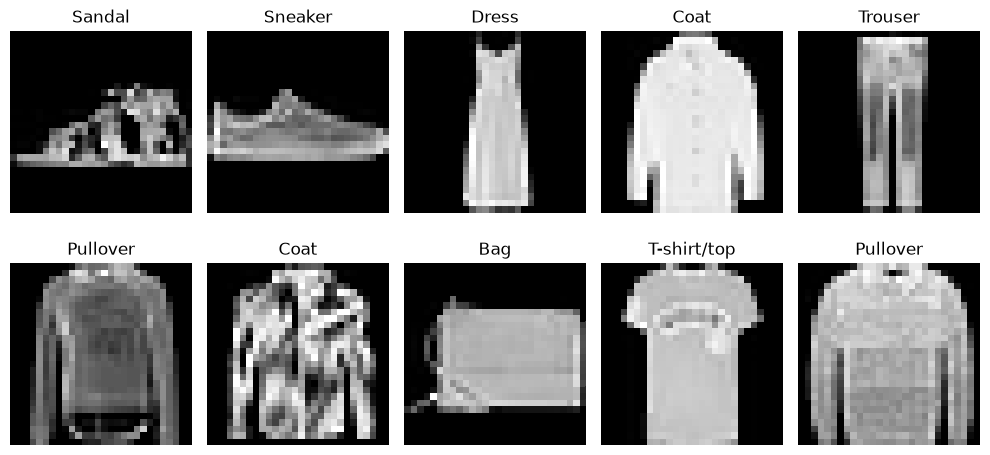

In [4]:
import matplotlib.pyplot as plt
# Verify the data looks as expected

start = 11
end = 21

plt.figure(figsize=(10,5))
for i in range(start, end):
    img = X_test[i]
    plt.subplot(2, 5, i-start+1) # only for current 10 pictures 
    plt.imshow(img, cmap='gray')
    plt.title(class_names[y_test.argmax(axis=1)[i]])
    plt.axis('off')
    
plt.tight_layout()
plt.show()


Reflection: Does the data look as expected? How is the quality of the images? Are there any issues with the dataset that you notice?

**Your answer here**

Yes, the images seem to be loaded and displayed correctly and they are not corrupted. <br>
Each label appears to match with the item in their corresponding image. <br>
The images are grayscale and have the correct orientation and resolution as expected. <br>
The objects are reasonably recognizable. <br>
There are no anomalies. <br>


# 2. Baseline Model

In this section, you will create a linear regression model as a baseline. This model will not use any convolutional layers, but it will help you understand the performance of a simple model on this dataset.
You should:
- [ ] Create a simple linear regression model using Keras.
- [ ] Compile the model with an appropriate loss function and optimizer.
- [ ] Train the model on the training set and evaluate it on the test set.

A linear regression model can be created using the `Sequential` API in Keras. Using a single `Dense` layer with no activation function is equivalent to a simple linear regression model. Make sure that the number of units in the output layer matches the number of classes in the dataset.

Note that for this step, we will need to use `Flatten` to convert the 2D images into 1D vectors before passing them to the model. Put a `Flatten()` layer as the first layer in your model so that the 2D image data can be flattened into 1D vectors.

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Flatten, Input
from keras.optimizers import SGD

# Create a simple linear regression model
model = Sequential()
# You can use `model.add(<layer>)` to add layers to the model
model.add(Input(shape=(28,28)))
model.add(Flatten())
model.add(Dense(10))
# Compile the model using `model.compile()`
model.compile(optimizer=SGD(learning_rate=0.003, momentum=0.5), loss='categorical_crossentropy')
# Train the model with `model.fit()`
model.fit(X_train, y_train)
# Evaluate the model with `model.evaluate()`
model.evaluate(X_test, y_test)

2026-07-12 16:36:44.214668: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 687us/step - loss: 4.8978
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 681us/step - loss: 4.5051


4.505108833312988

Reflection: What is the performance of the baseline model? How does it compare to what you expected? Why do you think the performance is at this level?

**Your answer here**

The performance of the model is 4.50511 loss which is bad, but, as the model was linear it was expected. The performance was bad at this level because the model didn't learn enough from the dataset because of not having proper number of layers, activation functions, size of layers, and etc.

# 3. Building and Evaluating a Simple CNN Model

In this section, you will build a simple Convolutional Neural Network (CNN) model using Keras. A convolutional neural network is a type of deep learning model that is particularly effective for image classification tasks. Unlike the basic neural networks we have built in the labs, CNNs can accept images as input without needing to flatten them into vectors.

You should:
- [ ] Build a simple CNN model with at least one convolutional layer (to learn spatial hierarchies in images) and one fully connected layer (to make predictions).
- [ ] Compile the model with an appropriate loss function and metrics for a multi-class classification problem.
- [ ] Train the model on the training set and evaluate it on the test set.

Convolutional layers are designed to accept inputs with three dimensions: height, width and channels (e.g., RGB for color images). For grayscale images like those in Fashion MNIST, the input shape will be (28, 28, 1).

When you progress from the convolutional layers to the fully connected layers, you will need to flatten the output of the convolutional layers. This can be done using the `Flatten` layer in Keras, which doesn't require any parameters.

In [6]:
from keras.layers import Conv2D, Input, MaxPool2D

# Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Create a simple CNN model
model = Sequential([Input(shape=(28,28,1))])
model.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(2, strides=2))
model.add(Flatten())
model.add(Dense(10, activation='softmax'))
model.compile(optimizer=SGD(learning_rate=0.045, momentum=0.5), loss='categorical_crossentropy', metrics=['accuracy'])
# Train the model
model.fit(X_train, y_train)
# Evaluate the model
model.evaluate(X_test, y_test)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8284 - loss: 0.4903
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8662 - loss: 0.3853


[0.3852941691875458, 0.8661999702453613]

In [7]:
from keras.layers import Conv2D, Input, MaxPool2D
import tensorflow as tf

# Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Create a simple CNN model
model = Sequential([Input(shape=(28,28,1))])
model.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(2, strides=2))
model.add(Flatten())
model.add(Dense(10, activation='softmax'))
model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['accuracy'])
# Train the model
model.fit(X_train, y_train)
# Evaluate the model
model.evaluate(X_test, y_test)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8455 - loss: 0.4422
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8762 - loss: 0.3572


[0.357207328081131, 0.8762000203132629]

Reflection: Did the CNN model perform better than the baseline model? If so, by how much? What do you think contributed to this improvement?

**Your answer here**

Yes, I chose two models with different optimizers, one with SGD with momentum and the other with adam.

The model with SGD with momentum has accuracy of 86.62% and loss of 0.3852, and the model with adam has accuracy of 87.62% and loss of 0.3572 so the model in both cases did perform much better now. <br>

Convolutional Neural Network (CNN) was the reason for the initial improvement, i.e. use of Conv2D, maxpooling, models with advanced optimizers like sgd with momentum and adam contributed to this great improvement. 

# 3. Designing and Running Controlled Experiments

In this section, you will design and run controlled experiments to improve the model's performance. You will focus on one hyperparameter and one regularization technique.
You should:
- [ ] Choose one hyperparameter to experiment with (e.g., number of filters, kernel size, number of layers, etc.) and one regularization technique (e.g., dropout, L2 regularization). For your hyperparameter, you should choose at least three different values to test (but there is no upper limit). For your regularization technique, simply test the presence or absence of the technique.
- [ ] Run experiments by modifying the model architecture or hyperparameters, and evaluate the performance of each model on the test set.
- [ ] Record the results of your experiments, including the test accuracy and any other relevant metrics.
- [ ] Visualize the results of your experiments using plots or tables to compare the performance of different models.

The best way to run your experiments is to create a `for` loop that iterates over a range of values for the hyperparameter you are testing. For example, if you are testing different numbers of filters, you can create a loop that runs the model with 32, 64, and 128 filters. Within the loop, you can compile and train the model, then evaluate it on the test set. After each iteration, you can store the results in a list or a dictionary for later analysis.

Note: It's critical that you re-initialize the model (by creating a new instance of the model) before each experiment. If you don't, the model will retain the weights from the previous experiment, which can lead to misleading results.

### Number of filters

In [ ]:
# A. Test Hyperparameters

from keras.layers import Conv2D, Input, MaxPool2D, Dropout
from keras.losses import CategoricalCrossentropy
import tensorflow as tf

# Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Controlled Experiments
filters_list = [32, 64, 128, 256]
filters_results = {}

for i in filters_list:
    model = Sequential([Input(shape=(28,28,1))])
    model.add(Conv2D(filters=i, kernel_size=(3,3), activation='relu'))
    model.add(MaxPool2D(2, strides=2))
    model.add(Flatten())
    model.add(Dense(10, activation='softmax'))
    model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['accuracy'])
    # Train the model
    model.fit(X_train, y_train)
    # Evaluate the model
    filters_results[i] = model.evaluate(X_test, y_test)

/home/myos/Desktop/DSI/MLF1/deep_learning/deep-learning-env/lib/python3.11/site-packages/keras/src/backend/tensorflow/nn.py:1360: UserWarning: "`categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8475 - loss: 0.4370
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8783 - loss: 0.3507
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8567 - loss: 0.4072
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8877 - loss: 0.3263
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8616 - loss: 0.3931
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8815 - loss: 0.3312
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 13ms/step - accuracy: 0.8662 - loss: 0.3825
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8870 - loss: 0.3159


In [11]:
filters_results

{32: [0.3506808280944824, 0.8783000111579895],
 64: [0.3263213038444519, 0.8877000212669373],
 128: [0.33124104142189026, 0.8815000057220459],
 256: [0.3159317970275879, 0.8870000243186951]}

The best number of filters is 256 as it provides accuracy of 0.887 and loss of 0.316

### Kernel size

In [ ]:
from keras.layers import Conv2D, Input, MaxPool2D
import tensorflow as tf

# Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Controlled Experiments
# filters_list = [32, 64, 128, 256]
# filters_results = {}
kernel_size = [3, 4, 5, 6]
kernel_size_results = {}

for i in kernel_size:
    model = Sequential([Input(shape=(28,28,1))])
    model.add(Conv2D(filters=32, kernel_size=(i,i), activation='relu'))
    model.add(MaxPool2D(2, strides=2))
    model.add(Flatten())
    model.add(Dense(10, activation='softmax'))
    model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['accuracy'])
    # Train the model
    model.fit(X_train, y_train)
    # Evaluate the model
    kernel_size_results[i] = model.evaluate(X_test, y_test)

/home/myos/Desktop/DSI/MLF1/deep_learning/deep-learning-env/lib/python3.11/site-packages/keras/src/backend/tensorflow/nn.py:1360: UserWarning: "`categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8413 - loss: 0.4509
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8591 - loss: 0.3796
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8399 - loss: 0.4572
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8763 - loss: 0.3632
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8403 - loss: 0.4557
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8632 - loss: 0.3812
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8347 - loss: 0.4702
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8643 - loss: 0.3772


In [13]:
kernel_size_results

{3: [0.3796156346797943, 0.8590999841690063],
 4: [0.3632426857948303, 0.8762999773025513],
 5: [0.3812011778354645, 0.8632000088691711],
 6: [0.37718504667282104, 0.864300012588501]}

Kernel size of 4 seems to perform better as it provides accuracy of 0.8763 and loss of 0.3632

### Number of layers

In [ ]:
from keras.layers import Conv2D, Input, MaxPool2D
from keras.losses import CategoricalCrossentropy
import tensorflow as tf

# Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Controlled Experiments
# filters_list = [32, 64, 128, 256]
# filters_results = {}
# kernel_size = [3, 4, 5, 6]
# kernel_size_results = {}

# for i in kernel_size:

model = Sequential([Input(shape=(28,28,1))])
model.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(2, strides=2))
model.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(2, strides=2))
model.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(2, strides=2))
model.add(Flatten())
model.add(Dense(10, activation='softmax'))
model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['accuracy'])
# Train the model
model.fit(X_train, y_train)
# Evaluate the model
model.evaluate(X_test, y_test)

/home/myos/Desktop/DSI/MLF1/deep_learning/deep-learning-env/lib/python3.11/site-packages/keras/src/backend/tensorflow/nn.py:1360: UserWarning: "`categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7661 - loss: 0.6498
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7987 - loss: 0.5437


[0.543699324131012, 0.7986999750137329]

Adding extra layers does help as well it provided accuracy of 0.7986999750137329 and loss of 0.543699324131012

### Dropout

In [ ]:
from keras.layers import Conv2D, Input, MaxPool2D
from keras.losses import CategoricalCrossentropy
import tensorflow as tf

# Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Controlled Experiments
# filters_list = [32, 64, 128, 256]
# filters_results = {}
# kernel_size = [3, 4, 5, 6]
# kernel_size_results = {}

# for i in kernel_size:

model = Sequential([Input(shape=(28,28,1))])
model.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(2, strides=2))
model.add(Dropout(rate=0.2))
model.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(2, strides=2))
model.add(Dropout(rate=0.2))
model.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(2, strides=2))
model.add(Dropout(rate=0.2))
model.add(Flatten())
model.add(Dense(10, activation='softmax'))
model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['accuracy'])
# Train the model
model.fit(X_train, y_train)
# Evaluate the model
model.evaluate(X_test, y_test)

/home/myos/Desktop/DSI/MLF1/deep_learning/deep-learning-env/lib/python3.11/site-packages/keras/src/backend/tensorflow/nn.py:1360: UserWarning: "`categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.7039 - loss: 0.8101
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7972 - loss: 0.5471


[0.5470906496047974, 0.7972000241279602]

Similarly, adding Dropout regularization does help as well.

### L2 Regularization

In [ ]:
# B. Test presence or absence of regularization
from tensorflow.keras.layers import Conv2D, Input, Dropout, MaxPool2D
from tensorflow.keras import regularizers
from keras.losses import CategoricalCrossentropy
import tensorflow as tf

# Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Controlled Experiments
# filters_list = [32, 64, 128, 256]
# filters_results = {}
# kernel_size = [3, 4, 5, 6]
# kernel_size_results = {}

# for i in kernel_size:
l2 = 1e-4

model = Sequential([Input(shape=(28,28,1))])
model.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu', kernel_regularizer=regularizers.l2(l2), padding='same'))
model.add(MaxPool2D(2, strides=2))
model.add(Dropout(rate=0.2))
model.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu', kernel_regularizer=regularizers.l2(l2), padding='same'))
model.add(MaxPool2D(2, strides=2))
model.add(Dropout(rate=0.2))
model.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu', kernel_regularizer=regularizers.l2(l2), padding='same'))
model.add(MaxPool2D(2, strides=2))
model.add(Dropout(rate=0.2))
model.add(Flatten())
model.add(Dense(10, activation='softmax'))
model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['accuracy'])
# Train the model
model.fit(X_train, y_train)
# Evaluate the model
model.evaluate(X_test, y_test)

/home/myos/Desktop/DSI/MLF1/deep_learning/deep-learning-env/lib/python3.11/site-packages/keras/src/backend/tensorflow/nn.py:1360: UserWarning: "`categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.7674 - loss: 0.6428
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8515 - loss: 0.4267


[0.426693856716156, 0.8514999747276306]

As we see the results, accuracy of 0.8515 and loss of 0.4267, Adding L2 Regularization was helpful as well and did make considerable improvements.

Reflection: Report on the performance of the models you tested. Did any of the changes you made improve the model's performance? If so, which ones? What do you think contributed to these improvements? Finally, what combination of hyperparameters and regularization techniques yielded the best performance?

**Your answer here**

Yes, 

1. increasing the number of filters did improve the models performance. 256 filters were the best one. It helped the model to have more diverse number of nodes with different amount of weights.
2. Increasing the kernel size was helpful as well. 4 kernels were adequate.
3. Adding more layers was helpful as well. It helped the model the learn the patterns of images better.
4. Adding Dropout was helpful as well. It provided randomized removal of nodes in each layer, therefore it prevented overfitting.
5. L2 Regularization was helpful too. It helped the model to generalize better and prevented it from overfitting.


# 5. Training Final Model and Evaluation

In this section, you will train the final model using the best hyperparameters and regularization techniques you found in the previous section. You should:
- [ ] Compile the final model with the best hyperparameters and regularization techniques.
- [ ] Train the final model on the training set and evaluate it on the test set.
- [ ] Report the final model's performance on the test set, including accuracy and any other relevant metrics.

In [29]:
from tensorflow.keras.layers import Conv2D, Input, Dropout, MaxPool2D, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras import regularizers
from keras.losses import CategoricalCrossentropy
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import tensorflow as tf

# Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Controlled Experiments
# filters_list = [32, 64, 128, 256]
# filters_results = {}
# kernel_size = [3, 4, 5, 6]
# kernel_size_results = {}

# for i in kernel_size:
l2 = 1e-5

model = Sequential([Input(shape=(28,28,1))])
model.add(Conv2D(filters=64, kernel_size=(4,4), activation='relu', kernel_regularizer=regularizers.l2(l2), padding='same'))
model.add(BatchNormalization())
model.add(MaxPool2D(2, strides=2))
model.add(Dropout(rate=0.1))
model.add(Conv2D(filters=128, kernel_size=(4,4), activation='relu', kernel_regularizer=regularizers.l2(l2), padding='same'))
model.add(BatchNormalization())
model.add(MaxPool2D(2, strides=2))
model.add(Dropout(rate=0.1))
model.add(Conv2D(filters=256, kernel_size=(4,4), activation='relu', kernel_regularizer=regularizers.l2(l2), padding='same'))
model.add(BatchNormalization())
model.add(MaxPool2D(2, strides=2))
model.add(Dropout(rate=0.2))
model.add(GlobalAveragePooling2D())
model.add(Dense(256, activation='relu', kernel_regularizer=regularizers.l2(l2)))
model.add(BatchNormalization())
model.add(Dropout(rate=0.2))
model.add(Dense(10, activation='softmax'))
model.compile(optimizer='Adam', loss=CategoricalCrossentropy(label_smoothing=0.05), metrics=['accuracy'])
callbacks = [ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6),
             EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
# Train the model
history = model.fit(X_train, y_train, epochs=40, batch_size=32, validation_split=0.1, callbacks=callbacks)
# Evaluate the model
model.evaluate(X_test, y_test)

Epoch 1/40
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 58s 33ms/step - accuracy: 0.8367 - loss: 0.7198 - val_accuracy: 0.8812 - val_loss: 0.6077 - learning_rate: 0.0010
Epoch 2/40
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 53s 32ms/step - accuracy: 0.8945 - loss: 0.5735 - val_accuracy: 0.8865 - val_loss: 0.5778 - learning_rate: 0.0010
Epoch 3/40
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 53s 32ms/step - accuracy: 0.9064 - loss: 0.5447 - val_accuracy: 0.9038 - val_loss: 0.5458 - learning_rate: 0.0010
Epoch 4/40
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 56s 33ms/step - accuracy: 0.9156 - loss: 0.5257 - val_accuracy: 0.9198 - val_loss: 0.5235 - learning_rate: 0.0010
Epoch 5/40
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 55s 33ms/step - accuracy: 0.9252 - loss: 0.5138 - val_accuracy: 0.9205 - val_loss: 0.5106 - learning_rate: 0.0010
Epoch 6/40
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 58s 34ms/step - accuracy: 0.9288 - loss: 0.5058 - val_accuracy: 0.9167 - val_loss: 0.5293 - learning_rate: 0.0010
Epoch 7/40
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 58s 34ms/step - accura

[0.502143383026123, 0.932699978351593]

In [30]:
predictions = model.predict(X_test)

ordinary_loss = CategoricalCrossentropy(
    label_smoothing=0.0
)(y_test, predictions)

print("Ordinary test loss:", ordinary_loss.numpy())

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
Ordinary test loss: 0.22207138


Reflection: How does the final model's performance compare to the baseline and the CNN model? What do you think contributed to the final model's performance? If you had time, what other experiments would you run to further improve the model's performance?

**Your answer here**

The model has achieved great improvement as it reached to the accuracy of 93.27%. The current model uses label smoothing and L2 Regularization, so its reported loss is calculated differently as I did above by calculating an ordinary test loss, as I did loss result is 0.2220. While the baseline model had loss of 4.505 which was unacceptable. <br>

After numerous number of tries I reached to this shape of model: 64 -> 128 -> 256 -> 256 -> 10 that is performing better. <br>

These contributed to the final model's performance: <br>

- Use of higher number of filters, increased the number of filters in deeper convolutional layers. <br>
- Having higher number of kernel size <br>
- Use of L2 Regularization and Dropout, helped reduce overfitting by discouraging the model from depending too heavily on individual weights or activations. <br>
- Same padding preserved the spatial dimensions before pooling, while pooling with a stride of two gradually reduced the feature-map dimensions. <br>
- BatchNormalization, helped stabilize the activations during training. <br>
- Use of advanced optimizer, adam, provided adaptive learning rates for individual model paramters and supported more effective optimization. <br>
- Use of GlobalAveragePooling2D (instead of Flatten()) - it removes the two spatial dimensions, height and width, by averaging them. Does similar job to Flatten, though Flatten preserves every spatial value, while GlobalAveragePooling2D produces one average value per feature map. <br>
- Label smoothing, It changed the target distribution from a strict one-hot vector such as [0, 0, 1, 0, 0, 0, 0, 0, 0, 0] to approximately [0.005, 0.005, 0.955, 0.005, 0.005, 0.005, 0.005, 0.005, 0.005, 0.005]. This discouraged the model from becoming excessively confident and may have contributed to better generalization. <br>
- Use of callbacks, ReduceLROnPlateau and EarlyStopping. <br>
  - ReduceLROnPlateau automatically lowers the optimizer's learning rate when validation loss stopped improving, allowing the optimizer to make smaller weight updates. <br>
  - EarlyStopping stopped training when the monitored validation loss did not improve for a specified number of epochs. It also restored the weights from the epoch with the best validation loss. This saved computational resources and helped prevent overfitting. <br>

If I have more time I would try more number of layers with more number of filters, both in different shapes of model structure. For example: forward triangle, backward triangle, reversed triangles back to back (or base to base), or reversed triangles head to head.

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.
### Submission Parameters:
* Submission Due Date: `23:59 PM - 26/10/2025`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_1.ipynb)
    * The Lab 1 notebook (labs/lab_1.ipynb)
    * The Lab 2 notebook (labs/lab_2.ipynb)
    * The Lab 3 notebook (labs/lab_3.ipynb)
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
* Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.
Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.
If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-7-help-ml`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.